# Tutorial

## Quality Control

To perform quality control of single-cell or single-nuclei RNA sequencing (sc/snRNA-seq) we have the `do.pp.importer_py()` function. We need to define a list of H5 files that have been generated from a mapping tool like CellRanger or STARsolo. Additionally, we need to provide the batch names for the samples, and additional metadata can be provided in the form of a dictionary.

The quality control involves filtering genes and cells:
- **Genes**: are removed on their expression levels. Genes expressed in low amount of cells are excluded. By default, we consider that a gene is excluded if it is expressed in less than 5 cells
- **Cells**: are removed based on different parameters, including: number of genes, mitochondrial content, doublets and number of UMI counts.
    - Mitochondrial content: cells with high mitochondrial content are excluded. We recomment assuming a maximum un 5 % for scRNA-seq and 3% for snRNA-seq
    - Doublets: we implemented three different approaches for the identification of neotypic doublets (i.e, doublets originating from the combination of two or more different cell-types). The available implementations are [scDblFinder](https://github.com/plger/scDblFinder), [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [Scrublet](https://github.com/swolock/scrublet).
    - Number of genes: cells are removed by absolute number of genes a lower and upper threshold can be set.
    - Number of UMI counts: cells can be removed using two approaches: absolute or quantiles. A lower and upper threshold can be set and a combination of both approaches can be used (e.g., an absolute lower threshold and filter cells on the upper quantile).

After the quality control per sample, the individual samples will be combined into one AnnData object and log-normalisation, scaling and highly variable genes  will be calculated. To evaluate the quality control the distribution of total UMI, number of genes and mitochondrial genes per cell will be plotted in a violin plot before and after the quality control. These plots will be saved in the folders containing the H5 files. Additionally, we also keep track on the number of cells and genes that have been removed in each quality control step.

First, we start setting up the environment and loading the required libraries

In [4]:
from session_info2 import session_info

# Set-Up
import dotools_py as do

%matplotlib inline


To show how the quality control works, we are going to use a public dataset from 10X from human blood of healthy and donors with a malignant tumor. We get the raw and the filtered H5 files generated by 10X.

In [2]:
do.dt.example_10x()

2025-06-08 19:56:46,216 - Downloading data to /tmp/dotools_datasets/


In [8]:
paths = ['/tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5',
         '/tmp/dootools_datasets/disease/outs/filtered_feature_bc_matrix.h5']

adata = do.pp.importer_py(paths=paths,
                          ids=['batch1', 'batch2'],
                          metadata={'condition':['healthy', 'disease']},  # Additional metadata information
                          batch_key='batch',  # Column in obs to save batch information
                          remove_doublets=True,
                          doublet_tool='scDblFinder',  # Tool to identify neotypic doublets
                          min_genes_in_cell=300,
                          min_cells_with_genes=5,
                          cut_mt=5,
                          n_reads=10_000,
                          min_counts=500,  # Filter cells with less than 500 genes
                          high_quantile=95  # Filter cells with the top 5% number of UMI counts
                          )

2025-06-08 20:06:08,355 - Reading batch1


reading /tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


2025-06-08 20:06:09,058 - Remove Cells with low number of genes


filtered out 14 cells that have less than 300 genes expressed


2025-06-08 20:06:09,124 - Remove Genes lowly expressed


...

extracting highly variable genes


... storing 'doublet_class' as categorical
... storing 'doublet_score' as categorical


    finished (0:00:00)


2025-06-08 20:06:40,062 - Run PCA


computing PCA
    with n_comps=50
    finished (0:00:00)


In [9]:
adata

AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'

We can now check the quality control plots for:

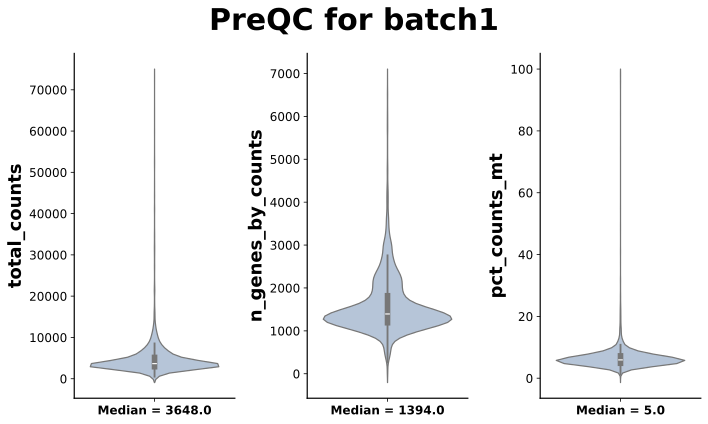

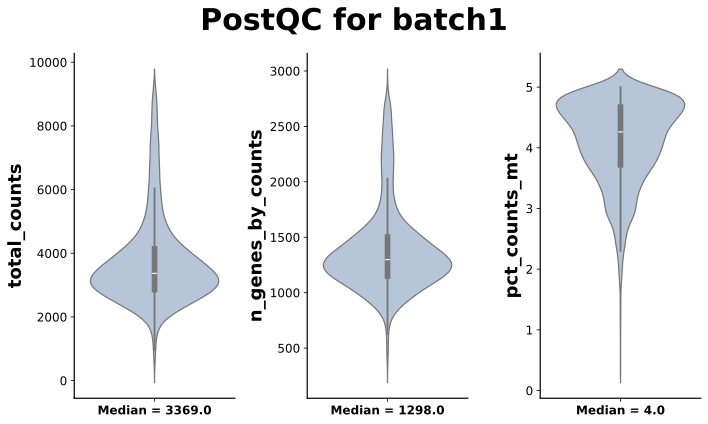

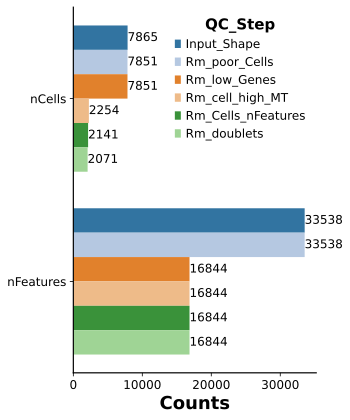

In [10]:
from IPython.display import SVG, display
display(SVG(filename='/tmp/dootools_datasets/healthy/outs/Vln_PreQC_batch1.svg'),
        SVG(filename='/tmp/dootools_datasets/healthy/outs/Vln_PostQC_batch1.svg'),
        SVG(filename='/tmp/dootools_datasets/healthy/outs/250608_QC_Metricsbatch1.svg')
        )

We can observe that the majority of cells were remove due to high mitochondrial content. Depending on the experimental set-up we might want to increase the threshold of mitochondrial content if we do not want to lose too many cells.

After the quality control, we can now proceed to the batch correction and integration of the samples. For these, we can use different batch correction methods: Harmony, Scanorama, BBKNN, scVI and CCA from Seurat (v4 or v5 approach). After the integration of the samples, we run the Leiden algorithm to find clusters and generate the UMAP embeddings for visualisation.

In [11]:
do.tl.integrate_data(adata,
                     batch_key='batch',
                     hvg_batch=True, # Take HVG shared across samples
                     cca4=True
                     )

2025-06-08 20:11:30,207 - Computing HVGs


extracting highly variable genes
    finished (0:00:00)
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:00)


2025-06-08 20:11:30,858 - Integration using CCA (Seurat v4 approach)
2025-06-08 20:11:30,862 - Preprocessing to export to Seurat
2025-06-08 20:11:30,926 - Running CCA Integration
Reading AnnData in R
Warning messages:
1: `PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
2: The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
3: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
Starting ACC in R environment...
Run CCA with v4
Scaling features for provided objects
Finding all pairwise anchors
Running CCA
Merging objects
Finding ne

computing PCA
    with n_comps=50
    finished (0:00:00)


2025-06-08 20:11:52,828 - Finding neighbors


computing batch balanced neighbors
	finished (0:00:00)


2025-06-08 20:11:53,703 - Run UMAP


computing UMAP
    finished (0:00:01)


2025-06-08 20:11:55,280 - Clustering cells using Leiden (resolution 0.3)


running Leiden clustering
    finished (0:00:00)


In [14]:
adata

AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score', 'leiden'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_CCA', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'distances', 'connectivities'

 We can observe, that after the integration we have `X_CCA` in `obsm`. This is the corrected expression matrix that is generated from running CCA in Seurat. In this case, we use the implementation from v4, so the dimensions of this matrix is  n_cells x n_hvg.

In [15]:
adata.obsm['X_CCA'].shape

(2801, 1766)

We can now visualise the integrated object and the identified clusters:

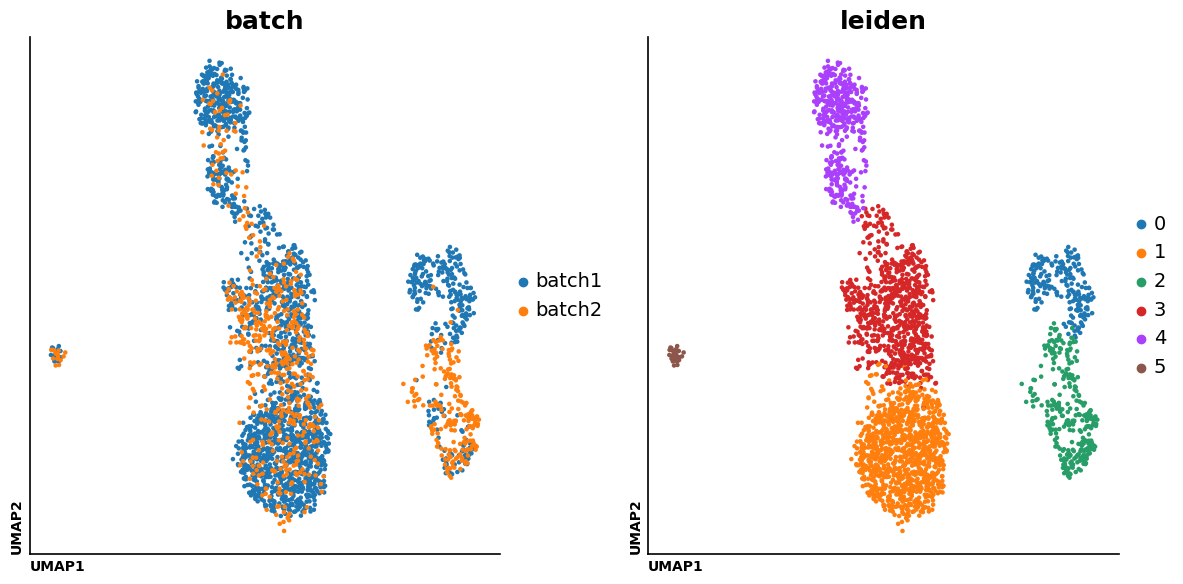

In [17]:
do.pl.umap(adata, ['batch', 'leiden'])

We also have the possibility to perform a semi-automatic annotation using CellTypist. In this case, we use the  `Adult_COVID19_PBMC.pkl` model.

In [18]:
adata = do.tl.auto_annot(adata, 'leiden', model='Adult_COVID19_PBMC.pkl', convert=False, pl_cell_prob=True)

👉 Detailed model information can be found at `https://www.celltypist.org/models`
🔬 Input data has 2801 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 2895 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


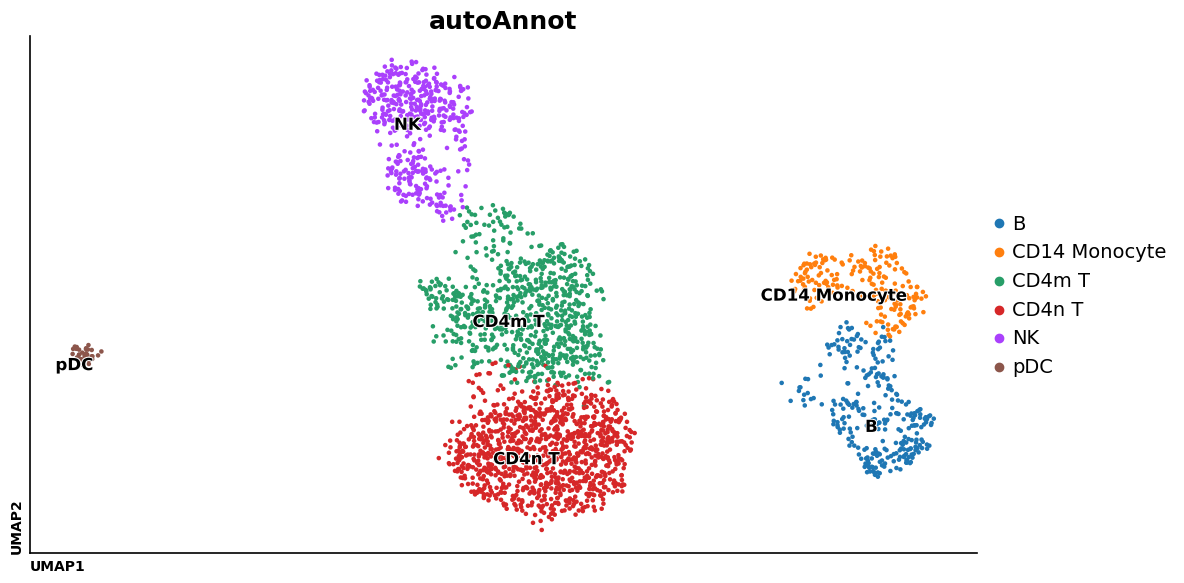

In [20]:
do.pl.umap(adata, 'autoAnnot', labels='autoAnnot')

After the identification of the cell populations, we can also evaluate if there are significant changes in these populations in the healthy and diseased condition using scanpro.

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[WARNING] Consider setting transform='arcsin', as this produces more accurate results for simulated data.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.26 seconds


2025-06-08 20:20:39,361 - There are 4 populations with a significant change


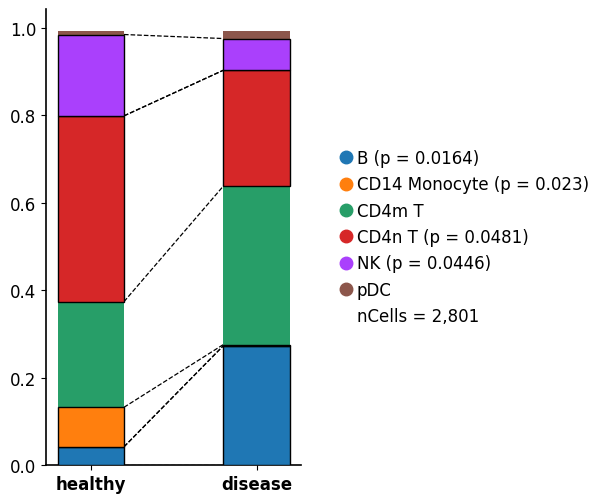

In [21]:
do.pl.cell_props(adata,
                 annot_key='autoAnnot',
                 cond_key='condition',
                 batch_key='batch',
                 cond_order=['healthy', 'disease'])

Cell populations with a significant change are connected by discontinued lines and the p-value is indicated in the legend. In this case, we see a significant change in B cells, CD14 Monocytes, CD4n T cells and NK cells assuming a significant threshold of 0.05.

We can visualise the expression of genes across conditions and cell-types with 3d dotplots:

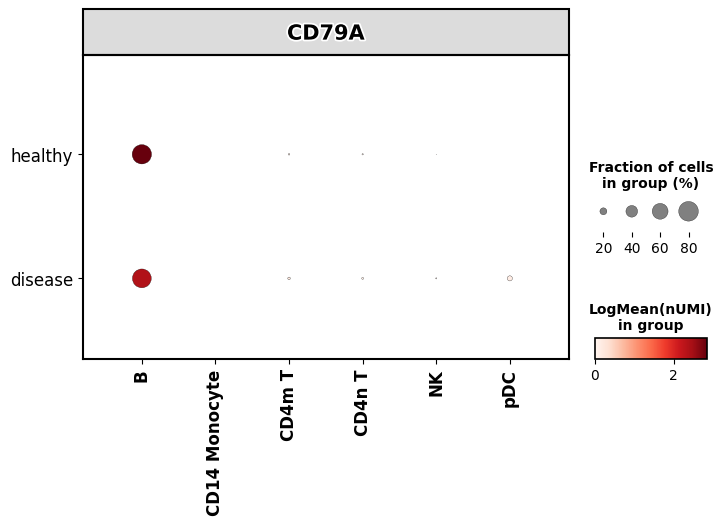

In [23]:
do.pl.dotplot(adata, 'autoAnnot', 'CD79A', y_axis='condition')

ranking genes


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished (0:00:07)


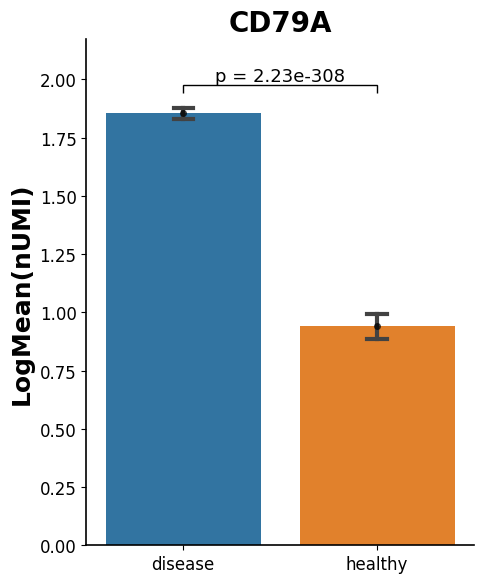

In [3]:
do.pl.barplot(adata, 'CD79A', 'condition', ctrl_cond='healthy', groups_cond='disease' )

In [25]:
adata.write('/tmp/dootools_datasets/adata.h5ad')

In [33]:
!pip list

Package                   Version     Editable project location
------------------------- ----------- ---------------------------------------------------
absl-py                   2.2.2
adjustText                1.3.0
aiobotocore               2.21.1
aiohappyeyeballs          2.6.1
aiohttp                   3.11.16
aioitertools              0.12.0
aiosignal                 1.3.2
anndata                   0.11.4
annotated-types           0.7.0
annoy                     1.17.3
anyio                     4.7.0
appnope                   0.1.2
archspec                  0.2.3
argon2-cffi               21.3.0
argon2-cffi-bindings      21.2.0
array_api_compat          1.11.2
asciitree                 0.3.3
asttokens                 3.0.0
async-lru                 2.0.4
async-timeout             5.0.1
attrs                     25.3.0
babel                     2.16.0
backports.tarfile         1.2.0
bbknn                     1.6.0
beautifulsoup4            4.12.3
bleach                    6.2.0
bl